## Credit fraud analysis

# I-Importing the data set and data exploration

## 1-Getting the data

In [2]:
## Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2-Data exploration

In [4]:
# Shape of our data set
shape=df.shape
print (f'Our data set has {shape[0]} rows and {shape[1]} columns')

Our data set has 284807 rows and 31 columns


In [5]:
#Data types of our data set

df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [6]:
# General informations about our data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
# Checking for missing values

# **Count of missings**
missings=df.isnull().sum()
missings.sort_values(ascending=False)

#missings propportions
missings_prop=df.isnull().sum()/len(df)*100
missings_prop.sort_values(ascending=False)

#Missing table
missing_table=pd.DataFrame({'Count':missings,
                            'proportion': missings_prop})
print (missing_table)


        Count  proportion
Time        0         0.0
V1          0         0.0
V2          0         0.0
V3          0         0.0
V4          0         0.0
V5          0         0.0
V6          0         0.0
V7          0         0.0
V8          0         0.0
V9          0         0.0
V10         0         0.0
V11         0         0.0
V12         0         0.0
V13         0         0.0
V14         0         0.0
V15         0         0.0
V16         0         0.0
V17         0         0.0
V18         0         0.0
V19         0         0.0
V20         0         0.0
V21         0         0.0
V22         0         0.0
V23         0         0.0
V24         0         0.0
V25         0         0.0
V26         0         0.0
V27         0         0.0
V28         0         0.0
Amount      0         0.0
Class       0         0.0


We don't have any missing values in our data set

In [8]:
# Checking for duplicate values

duplicates=df.duplicated().sum()
print(f'We have {duplicates} rows in our data set')

We have 1081 rows in our data set


In [9]:
# Removing duplicated rows
df.drop_duplicates(inplace=True)

#Now we verify
df.duplicated().sum()

0

# II-Exploratory data analysis (EDA)

## 1-Descriptive analysis of our variables

In [10]:
descriptive=df.describe(include='all')
print (descriptive)

                Time             V1             V2             V3  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean    94811.077600       0.005917      -0.004135       0.001613   
std     47481.047891       1.948026       1.646703       1.508682   
min         0.000000     -56.407510     -72.715728     -48.325589   
25%     54204.750000      -0.915951      -0.600321      -0.889682   
50%     84692.500000       0.020384       0.063949       0.179963   
75%    139298.000000       1.316068       0.800283       1.026960   
max    172792.000000       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  283726.000000  283726.000000  283726.000000  283726.000000   
mean       -0.002966       0.001828      -0.001139       0.001801   
std         1.414184       1.377008       1.331931       1.227664   
min        -5.683171    -113.743307     -26.160506     -43.557242   
25%        -0.850134      -0.6898

### a- Descriptive Analysis of our target variable

In [11]:
## To better understand our target variable 'class', we will create a new class_labeled variable 
## Class: The target variable. 1 if it is fraud, 0 otherwise.

df['class_labeled']= df['Class'].map({0:'otherwise', 1:'fraud'})
df['class_labeled'].unique()

array(['otherwise', 'fraud'], dtype=object)

In [12]:
## Number of fraud 

fraud_number=df['class_labeled'].value_counts()
print(f'{fraud_number}\n')

print(f"we have {fraud_number[1]} cases of fraud in our dataset\n ")

##Percentage of fraud

fraud_percentage=fraud_number/df.shape[0]*100
print(f'{fraud_percentage}\n')

##Fraud table
fraud_table=pd.DataFrame({'count_fraud': fraud_number,
                          'percentage_fraud': fraud_percentage})

fraud_table

class_labeled
otherwise    283253
fraud           473
Name: count, dtype: int64

we have 473 cases of fraud in our dataset
 
class_labeled
otherwise    99.83329
fraud         0.16671
Name: count, dtype: float64



C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_23896\1554495843.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"we have {fraud_number[1]} cases of fraud in our dataset\n ")


,count_fraud,percentage_fraud
class_labeled,,
otherwise,283253,99.83329
fraud,473,0.16671


We have an unbalanced daset according to our target variable with 

473 cases of fraud and 283253 of persons without fraud

### b- Visualization of the target

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_23896\1784545054.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Normal (0)', 'Fraude (1)'])


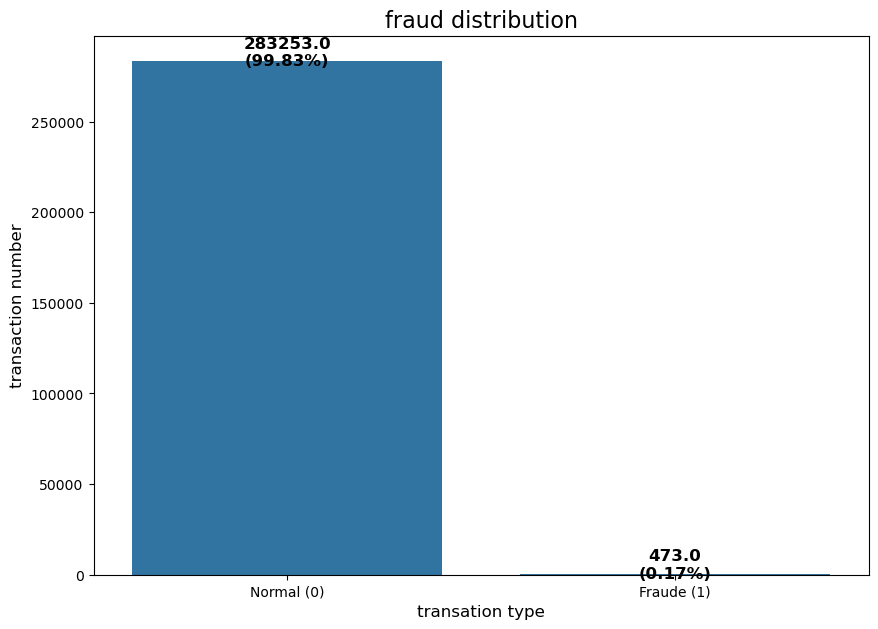

In [13]:
## Visualization of the fraud number with a count plot
total_transaction=len(df)

plt.figure(figsize=(10,7))
ax=sns.countplot(x='Class', data=df)
plt.title('fraud distribution', fontsize=16)
plt.xlabel('transation type',fontsize=12)
plt.ylabel('transaction number',fontsize=12)
ax.set_xticklabels(['Normal (0)', 'Fraude (1)'])

##Add the percentage and the count on patches
for p in ax.patches:
    height=p.get_height() #number of transactions
    
    #percentage of each patch
    percentage=100*(height / total_transaction)

    #text format
    label_text = f'{height}\n({percentage:.2f}%)'

    # tex position
    ax.text(p.get_x() + p.get_width() / 2.,  
            height + 5000,                  
            label_text,                     
            ha="center",                    
            va="center",                    
            fontsize=12,
            fontweight='bold')

plt.show()
    

## 2-Analysis of the "time" and "Amount" variables according to our target

The only two columns that we can easily interpret are Time and Amount. The others (V1 to V28) are

anonymised.

### a-Descriptive analysis

In [14]:
## We separe the data set in 2 parts based on the target

df_normal=df[df['Class']==0]
df_fraud=df[df['Class']==1]

#Descriptive statistics for normal transactions

print('Descriptive statistics for normal transactions\n')
print(df_normal[['Time','Amount']].describe())

print('Descriptive statistics for fraud transactions\n')
print(df_fraud[['Time','Amount']].describe())

Descriptive statistics for normal transactions

                Time         Amount
count  283253.000000  283253.000000
mean    94835.058093      88.413575
std     47475.550607     250.379023
min         0.000000       0.000000
25%     54233.000000       5.670000
50%     84711.000000      22.000000
75%    139308.000000      77.460000
max    172792.000000   25691.160000
Descriptive statistics for fraud transactions

                Time       Amount
count     473.000000   473.000000
mean    80450.513742   123.871860
std     48636.179973   260.211041
min       406.000000     0.000000
25%     41203.000000     1.000000
50%     73408.000000     9.820000
75%    129095.000000   105.890000
max    170348.000000  2125.870000


We can see that the average amount of normal transactions (88.41) is lower than that of fraudulent transactions (123.87). We can see that the average time for normal transactions is longer than that for fraudulent transactions.

### b-Visualization

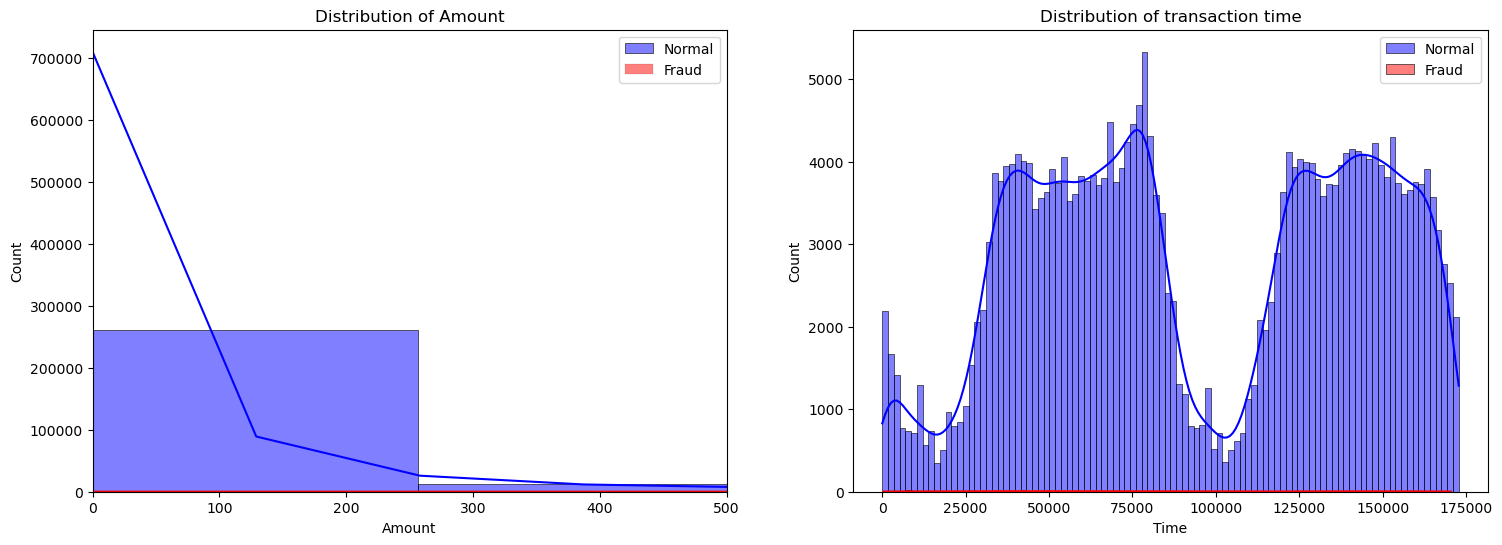

In [15]:
# Grph to see the differences
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))

# Histogram for 'Amount'
sns.histplot(df_normal['Amount'], bins=100, ax=ax1, color='blue', label='Normal', kde=True)
sns.histplot(df_fraud['Amount'], bins=50, ax=ax1, color='red', label='Fraud', kde=True)
ax1.set_title('Distribution of Amount')
ax1.set_xlim(0, 500) 
ax1.legend()

sns.histplot(df_normal['Time'], bins=100, ax=ax2, color='blue', label='Normal', kde=True)
sns.histplot(df_fraud['Time'], bins=100, ax=ax2, color='red', label='Fraud', kde=True)
ax2.set_title('Distribution of transaction time')
ax2.legend()

plt.show()

# III-Data preprocessing and feature engineering

## 1- Feature scaling

In [16]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,class_labeled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,otherwise
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,otherwise
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,otherwise
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,otherwise
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,otherwise
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,otherwise
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,otherwise
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,otherwise
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,otherwise


In [17]:
# Division of the data set in train and test set
from sklearn.model_selection import train_test_split
X=df.drop(['Class','class_labeled'], axis=1)
y=df['Class']
#We will use 80% of data for train and 20% for test
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler() # scaler object
df_scaled=df.copy() #create a copy of our dataset

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2-Logistic regression model without resampling our data set

We will try it to show the bad effects of unbalanced dataset using the scaled data set

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr=LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled,y_train) # train the model

#Predictions on train and test set
y_train_pred=lr.predict(X_train_scaled)
y_test_pred=lr.predict(X_test_scaled)

#Evaluation metrics on train
train_auc=roc_auc_score(y_train, y_train_pred)
train_classification_report=classification_report(y_train, y_train_pred)
train_confusion_matrix=confusion_matrix (y_train, y_train_pred)

print('\n---train_auc\n', train_auc)
print('\n---train_classification_report\n',train_classification_report)
print('\n---train_confusion_matrix\n',train_confusion_matrix)


#Evaluation metrics on test
test_auc=roc_auc_score(y_test, y_test_pred)
test_classification_report=classification_report(y_test, y_test_pred)
test_confusion_matrix=confusion_matrix (y_test, y_test_pred)

print('\n---test_auc\n', test_auc)
print('\n---test_classification_report\n',test_classification_report)
print('\n---test_confusion_matrix\n',test_confusion_matrix)



---train_auc
 0.8041621958533548

---train_classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       0.88      0.61      0.72       378

    accuracy                           1.00    226980
   macro avg       0.94      0.80      0.86    226980
weighted avg       1.00      1.00      1.00    226980


---train_confusion_matrix
 [[226570     32]
 [   148    230]]

---test_auc
 0.7893854245151988

---test_classification_report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746


---test_confusion_matrix
 [[56641    10]
 [   40    55]]


## 3-Oversampling the imbalanced data set

In [20]:
from imblearn.over_sampling import SMOTE

In [21]:
#Smote object and apply oversampling on training set
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


In [22]:
# Convert in a data frame

X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns) 
y_train_resampled_df = pd.DataFrame(y_train_resampled, columns=['Class']) 

df_oversampled = pd.concat([X_train_resampled_df, y_train_resampled_df], axis=1)

df_oversampled.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1.045499,1.147198,-1.042032,-1.428821,-1.817824,0.727198,2.695677,-1.489310,0.735746,-1.152704,...,-0.208573,-0.068205,0.445379,1.130202,-0.420363,-0.331281,0.092782,-0.156193,-0.229434,0
1,-0.298690,-0.677911,0.991948,0.394668,-0.025642,-0.301198,-0.728240,0.175615,0.629070,-1.156290,...,-0.332248,-1.307141,0.518036,0.851069,-1.367338,-0.554255,-0.049864,0.153831,-0.331197,0
2,0.678397,0.977654,0.016205,-1.386701,0.092688,0.850613,0.458823,-0.019872,0.154370,0.262056,...,0.405040,1.512732,-0.071350,-2.788905,0.202924,0.015479,0.111329,-0.165820,-0.298809,0
3,-0.074929,0.927561,0.195261,0.208736,2.739855,0.032003,0.772348,-0.613532,0.199999,0.625478,...,0.190793,0.966846,0.278559,1.160348,-0.407893,-0.021447,-0.049724,-0.119582,-0.289247,0
4,-1.376728,0.695218,-0.676118,0.363661,-1.090812,-0.882507,0.209618,-1.002620,0.182243,-1.911610,...,-0.473576,-0.878722,0.404329,-0.568164,-0.123705,-0.913882,0.155776,0.037290,-0.261985,0


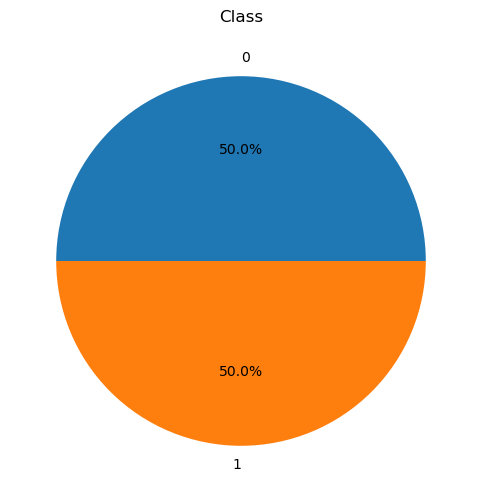

In [23]:
#Now we visualize the new distribution of the class variable
plt.figure(figsize=(8,6))
df_oversampled['Class'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Class")
plt.ylabel("")  
plt.show()

# IV- Modeling

## 1-Logistic regression

### a-Model training

In [25]:
#Training the model on the resampled data set
#We will use 80% of data for train and 20% for test

log=LogisticRegression(max_iter=1000)
log.fit(X_train_resampled,y_train_resampled) # train the model

LogisticRegression(max_iter=1000)

In [26]:
#Predictions and evaluation metrics on oversampled train set
y_train_pred=log.predict(X_train_resampled)

#Evaluation metrics on oversampled train set
train_auc=roc_auc_score(y_train_resampled, y_train_pred)
train_confusion_matrix=confusion_matrix(y_train_resampled, y_train_pred)
train_classification_report=classification_report(y_train_resampled, y_train_pred)

print('\n---train predictions\n---')
print('\n---train_auc---', train_auc)
print('\n---train_classification_report---\n',train_classification_report)
print('\n---train_confusion_matrix---\n',train_confusion_matrix)


---train predictions
---

---train_auc--- 0.9475534196520773

---train_classification_report---
               precision    recall  f1-score   support

           0       0.92      0.97      0.95    226602
           1       0.97      0.92      0.95    226602

    accuracy                           0.95    453204
   macro avg       0.95      0.95      0.95    453204
weighted avg       0.95      0.95      0.95    453204


---train_confusion_matrix---
 [[220794   5808]
 [ 17961 208641]]


In [27]:
#Predictions on scaled test set

y_test_pred = log.predict(X_test_scaled)


In [28]:
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"y_test_pred shape: {y_test_pred.shape}")


X_test_scaled shape: (56746, 30)
y_test shape: (56746,)
y_test_pred shape: (56746,)


In [29]:
#Evaluation metrics on test set
test_auc_score=roc_auc_score(y_test, y_test_pred)
test_confusion_matrix=confusion_matrix(y_test, y_test_pred)
test_classification_report=classification_report(y_test, y_test_pred)

print('\n---test predictions\n---')
print('\n---test_auc---', test_auc_score)
print('\n---test_classification_report---\n',test_classification_report)
print('\n---test_confusion_matrix---\n',test_confusion_matrix)


---test predictions
---

---test_auc--- 0.9237620184156178

---test_classification_report---
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


---test_confusion_matrix---
 [[55169  1482]
 [   12    83]]


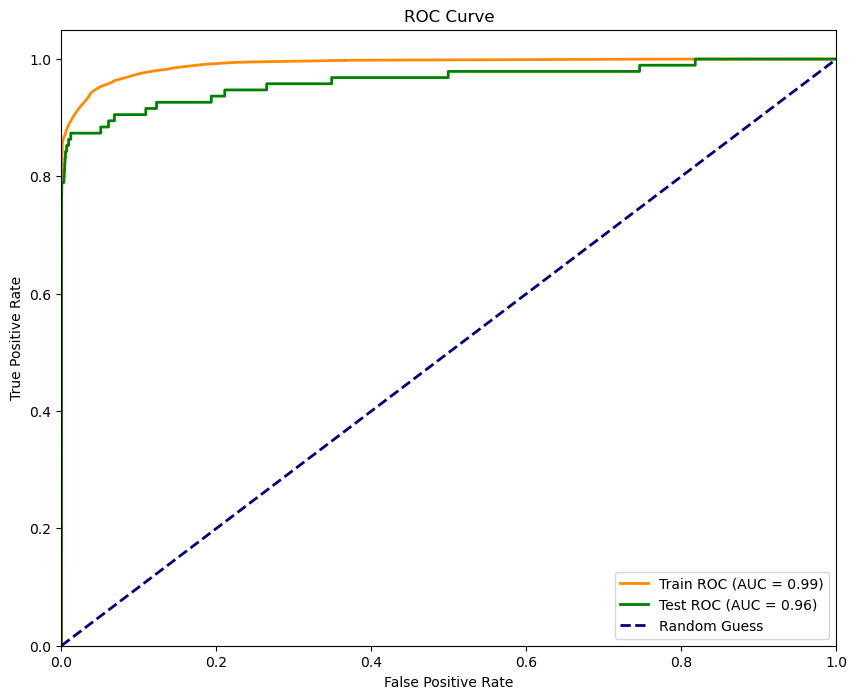

In [30]:
# Ploting the ROC curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probabilities
y_train_prob = log.predict_proba(X_train_resampled)[:, 1]  #probabilities for the over sampled set
y_test_prob = log.predict_proba(X_test_scaled)[:, 1]  #probabulities for the scaled set

# Compute ROC curve and AUC for train and test sets
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_train_prob)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test_scaled, y_test_prob)  
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='Train ROC (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='Test ROC (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Random Guess")

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### b-Most important variables to predict the fraud using our logictic regression model

Most important features:

   Feature  Coefficient  Absolute Coefficient  odds ratio
29  Amount     1.733192              1.733192    5.658690
14     V14    -1.615217              1.615217    0.198847
1       V1     1.521721              1.521721    4.580100
10     V10    -1.394056              1.394056    0.248067
4       V4     1.302286              1.302286    3.677696
12     V12    -1.289955              1.289955    0.275283
5       V5     0.981319              0.981319    2.667973
17     V17    -0.911388              0.911388    0.401966
20     V20    -0.756896              0.756896    0.469120
11     V11     0.669457              0.669457    1.953177
2       V2     0.657578              0.657578    1.930112
9       V9    -0.647213              0.647213    0.523503
6       V6    -0.632909              0.632909    0.531045
22     V22     0.588602              0.588602    1.801469
16     V16    -0.584008              0.584008    0.557659
8       V8    -0.574886              0.574886 

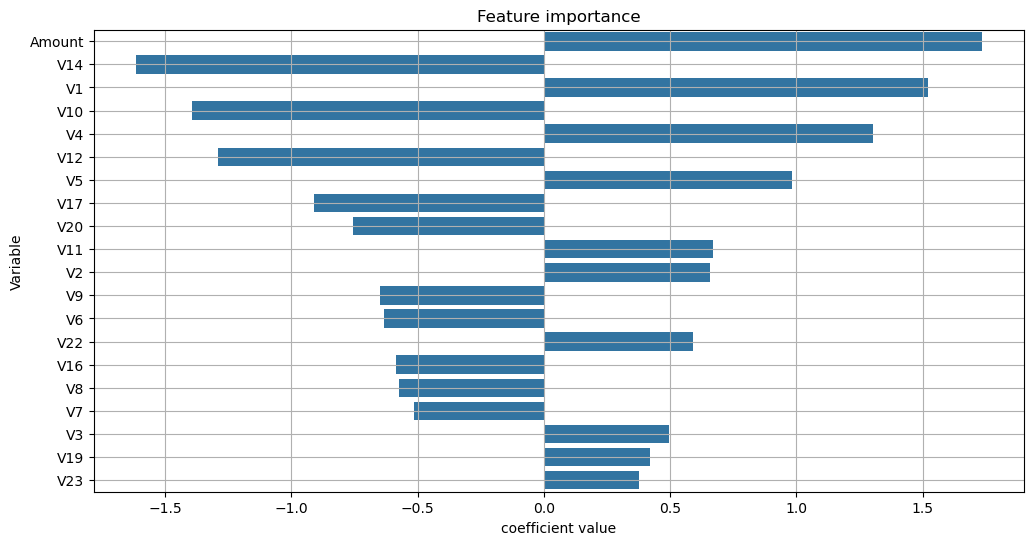

In [31]:
# Extraction of the coefficients of my model 

coefficients=log.coef_[0]
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefficients})

# Absolute value of the coefficients
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()

#Log odds of the coefficient
feature_importance['odds ratio']=np.exp(feature_importance['Coefficient'])

# Sorting the corfficients
feature_importance_sorted = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

print("Most important features:\n")
print(feature_importance_sorted.head(20))

#Visualisation of the results
plt.figure(figsize=(12,6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_sorted.head(20))
plt.title('Feature importance')
plt.xlabel('coefficient value')
plt.ylabel('Variable')
plt.grid(True)
plt.show()


In [32]:
# Saving the model
import joblib
joblib.dump(log, "logistic_model.pkl")

['logistic_model.pkl']

### c-Pipeline for scaling, oversampling and train the model

In [33]:
from imblearn.pipeline import Pipeline

In [34]:
pipeline=Pipeline([
    ('scaler', StandardScaler()),
    ('smote',SMOTE(random_state=42)),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

## 2-Random Forest model

### a-Random forest without optimization on the original data set

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(oob_score=True) # Out of bag
rf.fit(X_train, y_train) # training the model on the original data set

RandomForestClassifier(oob_score=True)

In [25]:
# Predictions on train and test set
y_train_pred=rf.predict(X_train)
y_test_pred=rf.predict(X_test)

In [26]:
# Performance evaluation of the random forest on train and test set
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score

#Performance on train and test set
train_accuracy=accuracy_score(y_train, y_train_pred)
train_recall=recall_score(y_train, y_train_pred)
train_auc=roc_auc_score(y_train, y_train_pred)

test_accuracy=accuracy_score(y_test, y_test_pred)
test_recall=recall_score(y_test, y_test_pred)
test_auc=roc_auc_score(y_test, y_test_pred)

#Table of metrics
performance_table=pd.DataFrame({
    'metrics':['accuracy', 'AUC', 'recall'],
    'train performance':[train_accuracy, train_auc, train_recall],
    'test performance':[test_accuracy,test_auc,test_recall]
})

print(performance_table)


    metrics  train performance  test performance
0  accuracy                1.0          0.999542
1       AUC                1.0          0.873667
2    recall                1.0          0.747368


In [27]:
test_classification_report=classification_report(y_test, y_test_pred)
print(test_classification_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.75      0.85        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



### b-Random Forest optimized with RandomizedSearchCV on the resampled scaled  data set

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np 

# Random Forest Model
rf_model = RandomForestClassifier(oob_score=True, random_state=42)

# Grid search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 8, 10, 15, None], 
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4]
}
#RandomizedSearchCV  parameters

random_search = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_grid, 
    n_iter=10, # number of iterations
    cv=3, 
    verbose=2, # dispplay the progression
    random_state=42, 
    n_jobs=-1 
)

print("randomized launch")
random_search.fit(X_train_resampled, y_train_resampled)


# Best parameters
print("\nbest parameters found:")
print(random_search.best_params_)

# Vous pouvez même récupérer le meilleur modèle directement
best_rf_model = random_search.best_estimator_

randomized launch
Fitting 3 folds for each of 10 candidates, totalling 30 fits

best parameters found:
{'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


In [29]:
#Training the model with the best parameters
random_forest=RandomForestClassifier(n_estimators=random_search.best_params_['n_estimators'],
                                     max_depth=random_search.best_params_['max_depth'],
                                     min_samples_leaf=random_search.best_params_['min_samples_leaf'],
                                     max_features=random_search.best_params_['max_features'],
                                     oob_score=True, random_state=42)

# Training the model on oversampled train set
random_forest.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(min_samples_leaf=2, n_estimators=300, oob_score=True,
                       random_state=42)

In [30]:
#Predictions and evaluation metrics on oversampled train set
y_train_pred=random_forest.predict(X_train_resampled)

#Evaluation metrics on oversampled train set
train_auc=roc_auc_score(y_train_resampled, y_train_pred)
train_confusion_matrix=confusion_matrix(y_train_resampled, y_train_pred)
train_classification_report=classification_report(y_train_resampled, y_train_pred)

print('\n---train predictions\n---')
print('\n---train_auc---', train_auc)
print('\n---train_classification_report---\n',train_classification_report)
print('\n---train_confusion_matrix---\n',train_confusion_matrix)


---train predictions
---

---train_auc--- 0.9999713153458486

---train_classification_report---
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       1.00      1.00      1.00    226602

    accuracy                           1.00    453204
   macro avg       1.00      1.00      1.00    453204
weighted avg       1.00      1.00      1.00    453204


---train_confusion_matrix---
 [[226589     13]
 [     0 226602]]


In [42]:
#Predictions on scaled test set

y_test_pred = random_forest.predict(X_test_scaled)

test_accuracy=accuracy_score(y_test, y_test_pred)
test_recall=recall_score(y_test, y_test_pred)
test_auc=roc_auc_score(y_test, y_test_pred)
test_classification_report=classification_report(y_test, y_test_pred)

print('\n ---test classification report\n---',test_classification_report)
print('\n---trest_auc---', test_auc)
print('\n---test_confusion_matrix---\n',test_confusion_matrix)


 ---test classification report
---               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746


---trest_auc--- 0.8736224287395866

---test_confusion_matrix---
 [[56641    10]
 [   40    55]]


The results indicate 91% accuracy for the fraud class, which is a significant increase compared to the initial evaluation. This means that the model correctly identifies most cases of fraud/

The recall of 75% shows that, among the fraud cases present in the data, three quarters are correctly detected. This represents a significant improvement over previous results, where the model only captured 58% in the logistic model.

The F1 score of 0.82 for the fraud class reflects a good balance between precision and recall, which is essential for a fraud detection model. It proves that the model is not only effective on the majority class, but that it is capable of correctly generalising fraud detection.

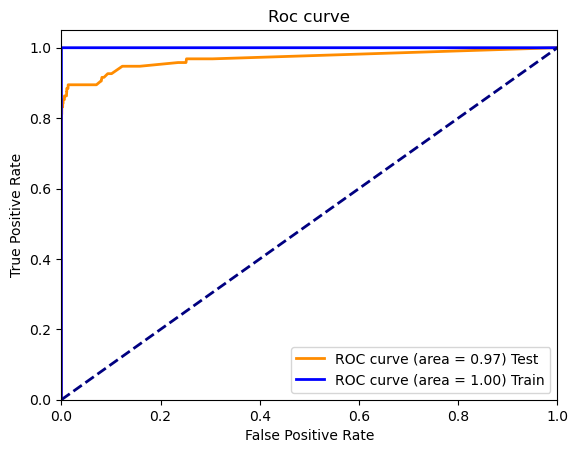

In [39]:
from sklearn.metrics import roc_curve, auc

#Probabilities
y_train_prob = random_forest.predict_proba(X_train_resampled)[:, 1]
y_test_prob = random_forest.predict_proba(X_test_scaled)[:, 1]

# True positive and false positive rate
train_fpr, train_tpr, _ = roc_curve(y_train_resampled, y_train_prob)
test_fpr, tpr_test, _ = roc_curve(y_test, y_test_prob)

#OC AUC for train and test set
roc_auc_test = auc(test_fpr, tpr_test)
roc_auc_train = auc(train_fpr, train_tpr)

# Roc Curve
plt.figure()
plt.plot(test_fpr, tpr_test, color='darkorange', lw=2, label='ROC curve (area = %0.2f) Test' % roc_auc_test)
plt.plot(train_fpr, train_tpr, color='blue', lw=2, label='ROC curve (area = %0.2f) Train' % roc_auc_train)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc curve')
plt.legend(loc="lower right")
plt.show()

With AUC of 0.97, this means that in 97% of cases, our model is able to correctly distinguish between a fraud and a normal transaction. This is a very robust measure of its classification ability.

### c-features importance

variable importance :
   Variable  Importance
0       V14    0.172438
1       V10    0.124606
2       V12    0.104681
3        V4    0.102140
4       V17    0.091420
5       V11    0.065189
6       V16    0.057664
7        V3    0.048241
8        V2    0.027796
9        V7    0.024750
10       V9    0.020488
11      V21    0.016878
12       V8    0.013608
13       V5    0.012552
14      V18    0.011831
15      V27    0.011809
16      V19    0.011567
17       V1    0.008235
18      V20    0.007854
19      V26    0.007644
20      V13    0.007491
21      V28    0.007456
22   Amount    0.007249
23      V15    0.006286
24       V6    0.006251
25      V24    0.004920
26      V25    0.004906
27      V23    0.004799
28      V22    0.004753
29     Time    0.004497


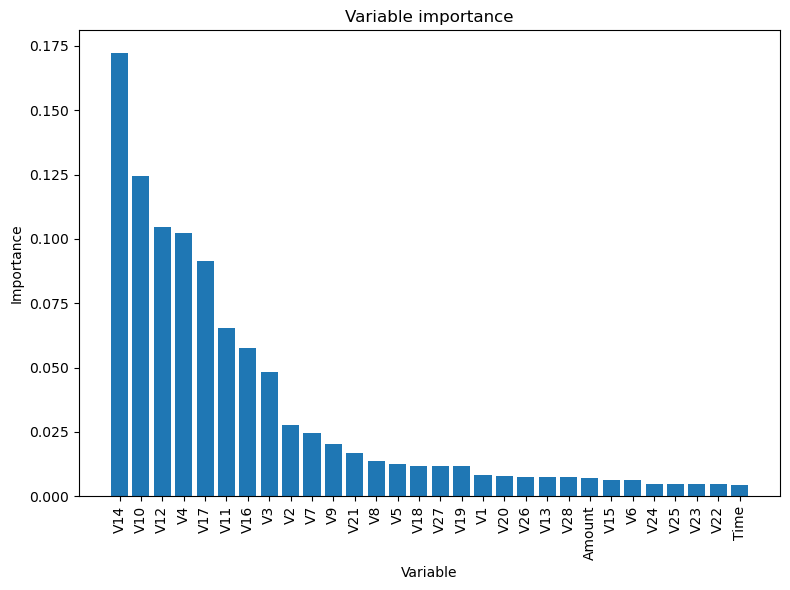

In [40]:
#Features importance
importance = random_forest.feature_importances_

# Data frame of the importance
importance_df = pd.DataFrame({'Variable': X.columns, 'Importance': importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the data frame
print("variable importance :")
print(importance_df)


# bar plot of features importance
plt.figure(figsize=(8, 6))
plt.bar(importance_df['Variable'], importance_df['Importance'])
plt.xticks(rotation='vertical')
plt.xlabel('Variable')
plt.ylabel('Importance')
plt.title('Variable importance')
plt.tight_layout()
plt.show()

## 3-XGBOOST (Extreme Gradient Boosting)

### a-xgboost model without optimization on the original data set

In [40]:
from xgboost import XGBClassifier

In [41]:
# Parameters of our xgboost classifier
params={
    'max depth':3, #max depth of each tree
    'eta': 0.3, #importance of each tree
    'objective':'multi:softprob',
    'num_class':2, #number of classes to predict
    'n_estimators':100 #number of trees
}

In [43]:
#Model training
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [45]:
#Predictions on train and test set
y_pred_train=xgb.predict(X_train)
y_pred_test=xgb.predict(X_test)

# Probabilities
y_pred_proba_test = xgb.predict_proba(X_test)[:,1]
y_pred_proba_train = xgb.predict_proba(X_train)[:,1]


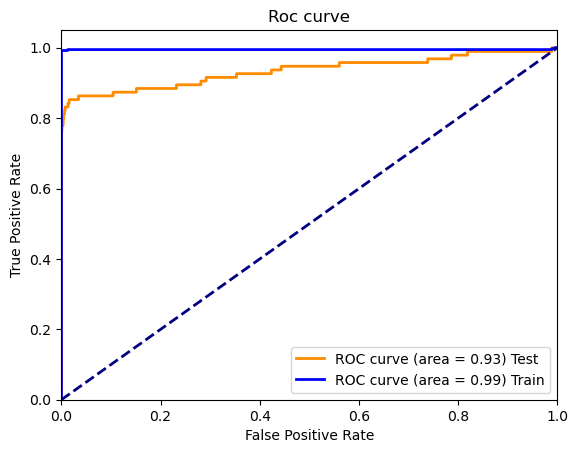

In [67]:
# Roc Curve for test
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)
roc_auc_test = auc(fpr_test, tpr_test)

# ROC curve for train
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
roc_auc_train = auc(fpr_train, tpr_train)

# Display the curve
plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label='ROC curve (area = %0.2f) Test' % roc_auc_test)
plt.plot(fpr_train, tpr_train, color='blue', lw=2, label='ROC curve (area = %0.2f) Train' % roc_auc_train)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc curve')
plt.legend(loc="lower right")
plt.show()



In [48]:
# Classification report for test
print("Classification report for test :")
print(classification_report(y_test, y_pred_test))

Classification report for test :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.81      0.73      0.77        95

    accuracy                           1.00     56746
   macro avg       0.91      0.86      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [49]:
# Classification report for train
print("Classification report for train :")
print(classification_report(y_train, y_pred_train))

Classification report for train :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       0.99      0.98      0.99       378

    accuracy                           1.00    226980
   macro avg       1.00      0.99      0.99    226980
weighted avg       1.00      1.00      1.00    226980



On our test set our model really identified 73% of fraud with a precision of 81%

### b-xgboost model with optimization (GridSearchCV) on the resampled scaled data set

In [52]:
import time
from sklearn.model_selection import  GridSearchCV

In [53]:
# The parameters to optimize will be the maximal depht, the learning rate and the number of trees

param_grid={
    'max_depth':[3,4,5,7,8],
    'n_estimators':[100,200,300,500,1000],
    'learning_rate':[0.01,0.1,0.2]
}
# Grid search
model=XGBClassifier()
grid_search=GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)


In [54]:
# Training the model
start_time=time.time()

#Training the model with GridSearchCV
grid_search.fit(X_train, y_train)
#Execution time
execution_time = time.time() - start_time

Fitting 5 folds for each of 75 candidates, totalling 375 fits


C:\Users\Yves-Ricky\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:19:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "max_depht" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [55]:
# Best parameters
print('Best parameters\n',grid_search.best_params_)
print("execution_time: %.2f seconds" % execution_time)

Best parameters
 {'learning_rate': 0.01, 'max_depht': 3, 'n_estimators': 1000}
execution_time: 2188.16 seconds


In [68]:
#Using the best xgboost model for predictions
best_xgb = grid_search.best_estimator_

#Predictions on train and test set
y_train_pred=best_xgb.predict(X_train_resampled)
y_test_pred = best_xgb.predict(X_test_scaled)

# Classification Report
print("\nTrain Classification Report:\n")
print(classification_report(y_train_resampled, y_train_pred))
print("\nTest Classification Report:\n")
print(classification_report(y_test, y_test_pred))
                              


Train Classification Report:

              precision    recall  f1-score   support

           0       0.79      1.00      0.88    226602
           1       1.00      0.73      0.84    226602

    accuracy                           0.86    453204
   macro avg       0.89      0.86      0.86    453204
weighted avg       0.89      0.86      0.86    453204


Test Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.66      0.79        95

    accuracy                           1.00     56746
   macro avg       0.98      0.83      0.89     56746
weighted avg       1.00      1.00      1.00     56746



Oour model successfully identified 66% of all actual fraud present in the test set zith q precision of 97%

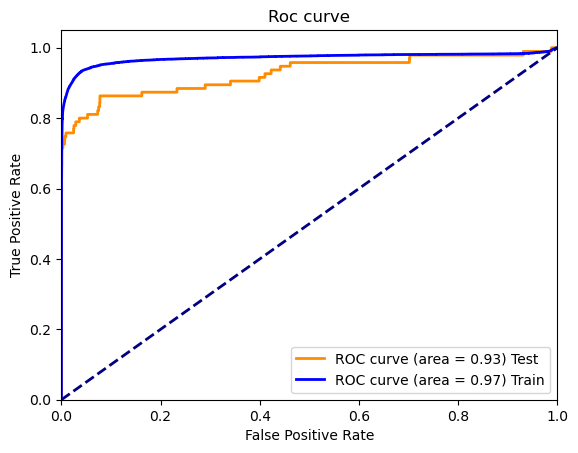

In [69]:
#Predict probabilities
# Probabilities
y_pred_proba_test = xgb.predict_proba(X_test_scaled)[:,1]
y_pred_proba_train = xgb.predict_proba(X_train_resampled)[:,1]

# Roc Curve for test
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_proba_test)
roc_auc_test = auc(fpr_test, tpr_test)

# ROC curve for train
fpr_train, tpr_train, _ = roc_curve(y_train_resampled, y_pred_proba_train)
roc_auc_train = auc(fpr_train, tpr_train)

# Display the curve
plt.figure()
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label='ROC curve (area = %0.2f) Test' % roc_auc_test)
plt.plot(fpr_train, tpr_train, color='blue', lw=2, label='ROC curve (area = %0.2f) Train' % roc_auc_train)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc curve')
plt.legend(loc="lower right")
plt.show()


With 0.93, this means that in 93% of cases, our model is able to correctly distinguish between a fraud and a normal transaction. This is a very robust measure of its classification ability.

### b-Features importance

   feature  importance
10     V10    0.298565
14     V14    0.274582
17     V17    0.138736
12     V12    0.040735
4       V4    0.024355
7       V7    0.017439
26     V26    0.012691
8       V8    0.012099
11     V11    0.012047
18     V18    0.010207
29  Amount    0.009918
21     V21    0.009728
3       V3    0.009538
16     V16    0.008753
20     V20    0.008710
28     V28    0.008474
5       V5    0.008439
27     V27    0.008324
1       V1    0.008297
2       V2    0.007672
22     V22    0.007628
6       V6    0.007506
9       V9    0.007455
19     V19    0.007395
24     V24    0.007201
15     V15    0.007022
25     V25    0.007012
0     Time    0.006956
13     V13    0.006465
23     V23    0.006052


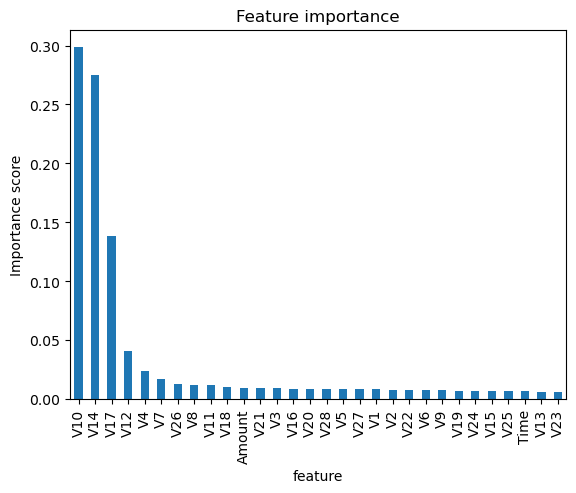

In [70]:
# Feature importance
importance_scores = best_xgb.feature_importances_

# Feature importance Data frame
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importance_scores
}).sort_values(by='importance', ascending=False)

print(importance_df)

# Feature importance bar plot
importance_df.set_index('feature').plot(kind='bar', legend=False)
plt.title('Feature importance')
plt.ylabel('Importance score')
plt.show()

‘Our model has an AUC of 0.93 because it has learned that features A, B, and C are the strongest predictors of our problem.’
Features V10 and V14 are the most important features of our model. Together, they account for more than 57% of the total importance (0.298 + 0.274).

In [ ]:
#Saving the model
import joblib
joblib.dump(best_xgb, 'fraud_detection_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Model and scaler saved !")

In [ ]:
# main.py

import joblib
import uvicorn
import numpy as np
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

# 1. Initialiser l'application FastAPI
app = FastAPI(title="API de Détection de Fraude", version="1.0")

# 2. Charger les artefacts (modèle et scaler) au démarrage
#    Cela évite de les recharger à chaque requête, c'est beaucoup plus efficace.
try:
    model = joblib.load('fraud_detection_model.joblib')
    scaler = joblib.load('scaler.joblib')
    print("Modèle et scaler chargés avec succès.")
except Exception as e:
    print(f"Erreur lors du chargement des artefacts : {e}")
    model = None
    scaler = None

# 3. Définir le format des données en entrée avec Pydantic
#    Cela garantit que les données reçues par l'API ont le bon format et les bons types.
#    Assurez-vous que les noms des champs correspondent EXACTEMENT aux noms des colonnes de votre DataFrame.
class Transaction(BaseModel):
    Time: float
    V1: float
    V2: float
    V3: float
    V4: float
    # ... Ajoutez toutes les variables V5 à V28 ici ...
    V28: float
    Amount: float

# 4. Créer le "endpoint" de prédiction
@app.post("/predict")
def predict(transaction: Transaction):
    """
    Reçoit les données d'une transaction et renvoie une prédiction de fraude.
    """
    if not model or not scaler:
        return {"error": "Modèle ou scaler non chargé. L'API n'est pas opérationnelle."}

    # Convertir les données d'entrée en DataFrame, puis en array NumPy
    # L'ordre des colonnes doit être le même que celui utilisé pour l'entraînement !
    data = pd.DataFrame([transaction.dict()])
    
    # Mettre les données à l'échelle avec le scaler CHARGÉ (ne pas le 'fit' à nouveau !)
    data_scaled = scaler.transform(data)
    
    # Faire la prédiction de probabilité
    # On prend la probabilité de la classe 1 (fraude)
    prediction_proba = model.predict_proba(data_scaled)[:, 1]
    
    # Définir un seuil de décision
    seuil = 0.5 # Vous pouvez ajuster ce seuil en fonction de votre analyse (courbe PR, etc.)
    
    # Formater la réponse
    is_fraud = bool(prediction_proba[0] > seuil)
    
    return {
        "prediction": "Fraude" if is_fraud else "Non-Fraude",
        "is_fraud": is_fraud,
        "score_de_fraude": float(prediction_proba[0])
    }

# Cette partie permet de lancer le serveur directement avec "python main.py"
if __name__ == "__main__":
    uvicorn.run(app, host="127.0.0.1", port=8000)